# Krachtactuator Ontwerpopdracht

In de eerste 4 weken van het vak DEF-D hebben jullie simulaties gedaan van verschillende opstellingen in de electrostatica. Jullie zijn in week 3.6 bij het vak electromagnetisme doorgegaan met de magnetostatica. Deze opdracht gaat in op het simuleren van deze magnetostatica.

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

De opdracht bestaat uit de volgende sub-onderdelen:
1) Afleiden van een analytische vergelijking
2) Criteria opstellen
3) Simuleren om de grenzen van jullie ontwerpparameters te bepalen
4) Numeriek berekenen van het magneetveld
5) Numeriek berekenen van het magneetveld van een solenoide
6) Bereken krachtrespons van een kracht actuator
7) Beoordeling van de criteria

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.9 beoordeeld en herkansingen zijn in week 3.10, zie de studiehandleiding voor details.

Technische Instructies:
- Download de zip map die op brightspace staat en unzip deze.
- Creëer een nieuwe branch in je Github repo voor deze opdracht.
- Plaats de geunzipte map op de juiste plek in jouw branch, zoals in de handleiding op brightspace staat.
- Nodig je teamgenoot uit als collaborateur op jouw repo.

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Probeer de voorbeeld code te begrijpen.
- Op een aantal plekken zijn voorbeelden gegeven of bepaalde numerieke methodes sterk versimpeld. Deze code kunnen reprocuderen is niet een leerdoel van dit vak en zal later in de opleiding voorkomen. Denk hierbij aan het integreren en differentieeren, probeer deze dingen wel te begrijpen.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# DEF-D opdracht 2: Ontwerp een solenoïdale krachtactuator


<img align="right" style="margin-left:15px" src="figures\solenoidactuator.png" width="600">


In deze ontwerpopdracht ga je een krachtactuator ontwerpen gebaseerd op een solenoïde en een permanente magneet. Deze lineaire krachtactuatoren worden gebruikt om bijvoorbeeld kleppen en afsluiters elektronisch te bedienen. Ook komen ze in vele huidshoudelijk apparaten voor. Hiernaast zie je een plaatje van een krachtactuator van de buitenkant en van de doorsnede. De krachtactuator bestaat uit een solenoïde (spoel), dat is een spiraalvormige stroomkring waar een stroom doorheen loopt. Zoals je weet kan je met een solenoide een redelijk homogeen veld maken als de solenoide lang en smal is. In de solenoïde  zit een cilinder,een zogeheten plunjer, die kan schuiven in de solenoïde. De plunjer is verbonden met het object dat je wilt bewegen. De plunjer kan gemaakt zijn van een magnetisch materiaal met een hoge magnetische permeabiliteit of van een permanente magneet. In dit voorbeeld kiezen we voor een plunjer van magnetiseerbaar materiaal.

Voor het ontwerpen van de actuator gaan we eerst de kracht van de actuator uitrekenen met behulp van analytische theorie. We nemen eerst aan dat de solenoïde ideaal is en leiden daarvoor een analytische vergelijking af. Nadat we een eerste ontwerp hebben gemaakt gebaseerd op de analytische oplossing gaan we simuleren hoe goed onze krachtactuator echt werkt en of we het ontwerp nog kunnen verbeteren. Daar gaan we!

## Deel 1: afleiden van een analytische vergelijking

Hier onder ze je een detaildoorsnede van de solenoïde. De solenoïde heeft een lengte $L_s$, $N$ wikkelingen, een straal $r_s$ en er loopt een constante stroom $I$ door de draad. De plunjer is een afstand $z_p$ in de solenoide geschoven en moet over een zo groot mogelijke afstand een kracht uitoefenen. Een ideale solenoïde heeft binnenin een constant veld dat overal langs de as is gericht, buiten de solenoïde is het veld nul. Daarnaast nemen we aan dat het magnetisch materiaal homogeen en lineair is en een relatieve permeabiliteit $\mu_r$ heeft.

<center>
<img src="figures\solenoidactuatorgraph.png" width="1000">
</center>

**Opdracht 1**

a. Pas de wet van Ampère toe voor het $\mathbf{H}$-veld met gebruik van contour $\cal C$.\
b. Leidt een vergelijking af voor het $\mathbf{B}$-veld als functie van $z_p$.\
c. Voldoet jouw afleiding aan de randvoorwaarden voor het H en B veld?

<img src="figures\DEF-D_Digital2_Deel1-opdr1a.png" width="1000">
<img src="figures\DEF-D_Digital2_Deel1-opdr1b.png" width="1000">
z< z_p is in de plunjer
<img src="figures\DEF-D_Digital2_Deel1-opdr1c.png" width="1000">
B loodrecht = 0

Het randveld van de solenoïde zal de plunjer de solenoïde intrekken. Echter, het berekenen van de randvelden is een hele klus, we zullen dit later doen. We gebruiken hier een aanpak soortgelijk aan die voor een dielektricum in een condensator. Allereerst berekenen we de totale energie van het systeem met behulp van $W = \frac{1}{2} \int_{\cal V} \mathbf{H} \cdot \mathbf{B} \, d\tau $. Daarna bepalen we de kracht op de plunjer door de afgeleide van de energie naar de positie te nemen. We nemen aan dat de plunjer dezelfde straal heeft als de solenoide, $r_s$. 

**Opdracht 2**

Bereken de totale hoeveelheid energie in de solenoïde als functie van $z_d$ door de veldenergie over het volume van de solenoïde te integreren met behulp van bovenstaande vergelijking.

<img src="figures\DEF-D_Digital2_Deel1-opdr2.png" width="1000">
<img src="figures\DEF-D_Digital2_Deel1-opdr2.png1.png" width="1000">=

Zoals je wellicht ziet uit je afleiding is de energie van de plunjer groter als de plunjer er geheel uit is en kleiner als de plunjer er geheel in is. De afgeleide van de energie naar de positie $z_p$ geeft dan ook een kracht die de plunjer naar buiten beweegt. Dit is fysisch niet wat er gebeurd. Wat we in de afleiding niet hebben meegenomen is de energie die het kost om de stroom te laten stromen. Het veranderende magneetveld veroorzaakt door het naar binnen bewegen van de magneet (wet van Faraday) geeft een stroom tegengesteld aan de aangelegde stroom, de stroombron moet dan dus meer vermogen gaan leveren om de stroom op gang te houden. Als we dit effect wel meenemen blijkt dat de grootte van de kracht gelijk is, maar dat deze dan de plunjer de solenoide intrekt. We gaan hier niet verder op in.


**Opdracht 3**

Bereken de kracht van de spoel op de plunjer.

<img src="figures\DEF-D_Digital2_Deel1-opdr3.png" width="1000">

## Deel 2: Criteria opstellen

Jullie gaan nu een magnetische kracht actuator ontwerpen hiervoor gaan jullie nu een ontwerpcyclus doorlopen.

**Opdracht 4**

a. Bedenk en schets vijf toepassingen van een kracht actuator.\
b. Kies uit deze toepassingen minimaal 2 toepassingen voor een kracht actuator om verder mee door te rekenen.

<figure>
  <img src="figures\DEF-D_Digital2_Deel2-opdr4.png" width="1000">
  <figcaption>We kiezen als toepassingen voor de prullenbak en de lichtnkop.</figcaption>
</figure>

**Opdracht 5**

We gaan nu verder kijken naar de criteria van jullie kracht actuatoren. Wij hebben alvast twee essentiele criteria vastgesteld zodat we hier later in de opdracht mee verder kunnen rekenen. Hieronder zijn 4 veelgebruikte stroombronnen benoemd die jullie gaan gebruiken voor een van de criteria.

| Spanningsbron             | Stroomsterkte | Voltage | draad dikte van de spoel |
|:--------------------------|:--------------|:--------|:-------------------------|
| Arduino uno digital pin   | 40 mA         | 5 V     | 0.05 mm                  |
| 9 Volt batterij           | 500 mA        | 9 V     | 0.1  mm                  |
| 40 Watt telefoon oplader | 2 A           | 20 V    | 0.2 mm                   |
| Een auto batterij         | 180 A         | 12 V    | 1.5 mm                   |


a. Kies een van de hierboven benoemde stroombronnen om te gebruiken in jullie ontwerp. \
b. Gebruik de methode uit het college 'schattend rekenen' om voor elke toepassing de minimale kracht die de actuator moet kunnen leveren voor jullie toepassing te bepalen.\
c. Denk na over wat de straal van jullie actuator mag zijn. \
d. Bedenk nog 1 ander criterium per toepassing.

b. <img src="figures\DEF-D_Digital2_Deel2-opdr5.png" width="1000">

c. Bij een een kracht van circa 10 N en een stroom van 2 A voor 40 Watt telefoonoplader, schat ik dat er ongeveer een straal van 1 cm voor de spoel nodig is. Een erg grote straal (>10 cm) wekt namelijk een erg grote/ wellicht te grote kracht op. En een grote straal heeft ook een groot aantal windingen nodig. Een groot aantal windingen verhoogt de weerstand van je draad omdat elke winding langer is. Dit kan de kracht juist weer minderen. Ik denk dat 1 cm een goede tussenweg is. Bij een kleine straal (<1cm) kan de lengte van de spoel ook niet te groot worden, aangezien dit resulteert in een te lage kracht. Een redelijke lengte van Ls is wel nodig om uberhaupt beweging te veroorzaken bij de plunjer.

Voor een lichtschakelaar geeft de 9 Volt batterij genoeg stroom. Een digitale pin van een Arduino levert maximaal $40$ mA en dit is te weinig om een sterk genoeg magnetisch veld op te wekken. Een lichtschakelaar heeft een kleine straal nodig, ongeveer 0.005 m.  Een pedaalemmer heeft een grotere straal nodig, ongeveer 0.015 m. Bij de pedaalemmer is de 20 volt batterij ideaal, omdat een hoog vermogen heeft en genoeg kracht van leveren.


d. De criteria voor de prullenbakactuator zijn een minimale openingshoek van 60 graden en een geleverde kracht van 17 N bij een stroomsterkte van 2 A. De criteria van de lichtschakelaar waren dat het in 0.1 sec moet worden omgeschakeld en dat de benodigde kracht van 3 N moet worden geleverd mbv een stroomsterkte van 0.5 A.

## Deel 3: Simuleren om de grenzen van jullie ontwerpparameters te bepalen

Jullie zullen nu simulaties gaan uitvoeren om de grenzen van jullie ontwerpparameters op te zoeken. Dit doen jullie voor jullie twee gekozen toepassingen en een deuractuator. Deze deuractuator moet een deur van het slot afhaalen door een kracht van 40 N uit te oefenen, gebruikt een 9 volt batterij als stroombron, de plunjer is gemaakt van ijzer en de straal van de actuator is 0.01 m.

**Opdracht 6**

Zet de relevante parameters in een Python script en maak een Python functie die met behulp van de wet van Ohm de maximale draadlengte uitrekent. Print de maximale draadlengte bij het uitvoeren van het script.

Plaats in deze cel een png met jullie eventuele analytische uitwerkingen.

In [17]:
###
###Hier jouw code###
# relevante parameters
rho_koper = rho_koper = 1.68e-8     # Soortelijke weerstand koper in Ohm*meter
# Deuractuator (40 N)
# Een deurklink moet ongeveer over 5 cm kracht worden geleverd van 40 N: Arbeid= 40 * 0.05 = 2 J . In een halve sec = 4 watt. (komt het meest in de buurt van batterij)
# plunjer is ijzer
    # Arduino (vermogen= 0.2 Watt), 40 mA, 5 v, 0.05 mm
    # Batterij (vermogen= 4.5 Watt), 500 mA, 9 V, 0.1 mm
    # telefoonoplader (vermogen= 40 Watt), 2 A, 20 V, 0.2 mm
    # autobatterij (vermogen= 2160 Watt), 180 A, 12 V, 1.5 mm
U_batteryd = 9       # volt
I_batteryd = 500/ 1000       # A
draaddikte_spoeld = 0.1/1000 # m
F_deur = 40 # N
r_sd = 0.01 # straal van de spoel

# prullenbak (17 N)
# Een pedaalemmer moet ongeveer 10 cm worden ingedrukt met een kracht van 17 N: Arbeid = 17 * 0.1 = 1.7 Watt. Dit moet in 0.5 sec moeten gebeuren: P = 3.4 Watt
# Omdat 9 V batterij hoge interne weerstand heeft, is telefoonoplader beter
# telefoonoplader (vermogen= 40 Watt), 2 A, 20 V, 0.2 mm
F_prullenbak = 17 # N
U_batteryp = 20 # V
I_batteryp = 2 #A
draaddikte_spoelp = 0.2/1000 # m
r_sp = 0.015 # m

# lichtschakelaar (3 N)
# Een lichtaschakelaar moet ongeveer 3 cm worden ingedrukt met een kracht van 3 N : Arbeid = 3 * 0.03 = 0.09 Watt. In 0.2 sec : P = 0.45 Watt (Batterij)
# Batterij (vermogen= 4.5 Watt), 500 mA, 9 V, 0.1 mm
F_lichtschakelaar = 3 # N
U_batteryl = 9 # V
I_batteryl = 500/1000 #A
draaddikte_spoell = 0.1/1000 # m
r_sl = 0.005 # m

# wet van Ohm
def wet_ohm_R(U,I):
    return U/I

# oppervlak van doorsnede draad
def bereken_A_draad(draaddikte_spoel):
    return (draaddikte_spoel / 2)**2 * np.pi
# straal_draad = draaddikte_spoel / 2
# A_draad = np.pi * (straal_draad**2)
# R = rho * (L / A)
def bereken_max_lengte(R, A, rho):
    return (R * A) / rho
# aanname dat het draad om de spoel van koper is
# deur
R_batteryd = wet_ohm_R(U_batteryd,I_batteryd)
A_draad_d = bereken_A_draad(draaddikte_spoeld)
print('De maximale R_battery is :',R_batteryd,'Ohm')
max_L_s = bereken_max_lengte(R_batteryd, A_draad_d, rho_koper)     # max lengte van de spoel
print(f'De maximale draadlengte is: {max_L_s:.2f} meter')
# prullenbak
R_batteryp = wet_ohm_R(U_batteryp,I_batteryp)
A_draad_p = bereken_A_draad(draaddikte_spoelp)
print('De maximale R_battery is :',R_batteryp,'Ohm')
max_L_s = bereken_max_lengte(R_batteryp, A_draad_p, rho_koper)     # max lengte van de spoel
print(f'De maximale draadlengte is: {max_L_s:.2f} meter')
# lichtschakelaar
R_batteryl = wet_ohm_R(U_batteryl,I_batteryl)
A_draad_l = bereken_A_draad(draaddikte_spoell)
print('De maximale R_battery is :',R_batteryl,'Ohm')
max_L_s = bereken_max_lengte(R_batteryl, A_draad_l, rho_koper)     # max lengte van de spoel
print(f'De maximale draadlengte is: {max_L_s:.2f} meter')
###

De maximale R_battery is : 18.0 Ohm
De maximale draadlengte is: 8.41 meter
De maximale R_battery is : 10.0 Ohm
De maximale draadlengte is: 18.70 meter
De maximale R_battery is : 18.0 Ohm
De maximale draadlengte is: 8.41 meter


**Opdracht 7**

Leidt een vergelijking af voor het minimale aantal wikkelingen $N$ die je nodig hebt om het gewicht op te kunnen tillen. Voeg je afleiding als png toe aan je notebook.

<img src="figures\DEF-D_Digital2_Deel3-opdr7.1.png" width="1000">

We gaan nu de ontwerpvrijheid verkennen. Gegeven de materiaalparameters en de eigenschappen van de stroombron kunnen we de verhouding tussen de lengte en de straal van de solenoide kiezen.

**Opdracht 8**

Schrijf een enkele Python functie die het minimum en maximum aantal wikkelingen uitrekent als functie van $L_s$, $r_s$, $r_d$ en $I$. De functie moet de volgende voorwaarden controleren
1) Het minimum aantal wikkelingen wordt gegeven door de hiervoor afgeleide relatie van het aantal wikkelingen om de benodigde kracht te genereren. 
2) Het maximum aantal wikkelingen wordt gegeven door de draaddikte $r_d$ en de lengte $L_s$
3) Het maximum aantal wikkelingen wordt gegeven door de draadlengte en de straal van de solenoide
4) Het maximum aantal wikkelingen moet groter zijn dan het minimum aantal wikkelingen

Het maximum aantal wikkelingen is de kleinste van voorwaarde 2) en 3). Geef een foutmelding als het minimum aantal windingen groter is dan het maximum aantal windingen.

Plaats hier een png met jullie eventuele analytische afleiding.

Een parameter plot geeft ons inzicht in de haalbaarheid van het idee. In dit geval willen we kijken naar het mogelijke aantal wikkelingen en de lengte van onze solenoide. Hieronder staat een voorbeeld van code die een voorbeeld plot creëert met minimale eis $y=x$ en de maximale eis $y=2x$.

Text(0, 0.5, 'y')

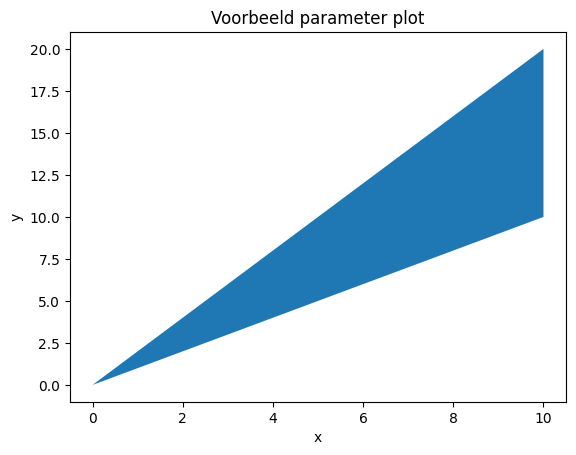

In [18]:
x = np.linspace(0,10,100)
y_min = x # Minimale eis
y_max = 2*x # Maximale eis

plt.fill_between(x,y_min,y_max) # De ruimte tussen de eisen vullen
plt.title("Voorbeeld parameter plot")
plt.xlabel("x")
plt.ylabel("y")


**Opdracht 9**

Maak een parameterplot met behulp van bovenstaand gedefinieerde functie voor de drie solenoideactuatoren voor $L_s$ tussen 0 en 1 m in 50 stappen. Een parameter plot ziet er hier uit als een plot tussen het minimale aantal wikkelingen en het maximaal aantal wikkelingen.



In [19]:
### BEGIN SOLUTION
###### NIEUW ########
mu_r = 20000 # geen eenheid, voor weekijzer
# voor deur met 40 N
# Hier heb je 9 volt batterij voor nodig met 500 mA en draaddikte van 0.1 mm
# I = 0.5 A
# straal actuator : 0.01 m
# Batterij (vermogen= 4.5 Watt), 500 mA, 9 V, 0.1 mm
relevante_parameters1 = {
    'r_s': 0.01,    # Straal solenoïde (m)
    'r_d': 0.1/2000,  # Straal draad (m)
    'I': 0.5,       # Stroom (A)
    'V': 20,         # volt
    'F_nodig': 40  # Benodigde kracht (N)
}
# voor een prullenbak
# 40 Watt telefoonoplader, 2 A, 20 V, 0.2 mm
relevante_parameters2 = {
    'r_s': 0.015,    # Straal solenoïde (m)
    'r_d': 0.1/1000,  # Straal draad (m)
    'I': 2,       # Stroom (A)
    'V': 20,         # volt
    'F_nodig': 17  # Benodigde kracht (N)
}

# voor lichtschakelaar
# Batterij
# Batterij (vermogen= 4.5 Watt), 500 mA, 9 V, 0.1 mm
relevante_parameters3 = {
    'r_s': 0.005,    # Straal solenoïde (m)
    'r_d': 0.1/2000,  # Straal draad (m)
    'I': 500/1000,       # Stroom (A)        
    'V': 9,         # volt
    'F_nodig': 3  # Benodigde kracht (N)
}
def aantal_wikkelingen(relevante_parameters):
    # Voeg hieronder de formules voor het maximum en minimum aantal wikkelingen.
    # constantes
    mu_0 = 4 * np.pi * 10**-7       # (m*T)/A
    A = np.pi * ( relevante_parameters['r_s'])**2
    N_min = (relevante_parameters['L_s'])/(relevante_parameters['I'] ) * (np.sqrt( (2 * relevante_parameters['F_nodig']) / (mu_0 * A * (mu_r - 1))) )
    # Maximum op basis van draaddikte en lengte (hoeveel passen er naast elkaar?)
    N_max_1 = relevante_parameters['L_s'] / (2 * relevante_parameters['r_d'])
    # Maximum op basis van draadlengte en straal, totaaal oppervlak gedeeld door het oppervlak van de doorsnede (cirkel)
    N_max_2 = (relevante_parameters['V'] * (relevante_parameters['r_d'])**2) / (2 * rho_koper * relevante_parameters['r_s'] * relevante_parameters['I'])
    #N_max_2 = (relevante_parameters['L_s'] * relevante_parameters['r_s']) / (relevante_parameters['r_d']**2)
    N_max = min(N_max_1,N_max_2)
    if N_min > N_max:
        # Gebruik rel_par['F_nodig'] in de print.
        print(f"The design with {relevante_parameters['F_nodig']:.1f} N has no workable solution")
        # print('The design with L_s=%.2f m has no workable solution'%L_s)
        N_min = 'NaN'
        N_max = 'NaN'
    
    return N_min, N_max

#N_min1, N_max1 = aantal_wikkelingen(relevante_parameters1)
#print(f"Minimum wikkelingen: {N_min1}")
#print(f"Maximum wikkelingen: {N_max1}")

#N_min2, N_max2 = aantal_wikkelingen(relevante_parameters2)
#print(f"Minimum wikkelingen: {N_min2}")
#print(f"Maximum wikkelingen: {N_max2}")

#N_min3, N_max3 = aantal_wikkelingen(relevante_parameters3)
#print(f"Minimum wikkelingen: {N_min3}")
#print(f"Maximum wikkelingen: {N_max3}")

The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable s

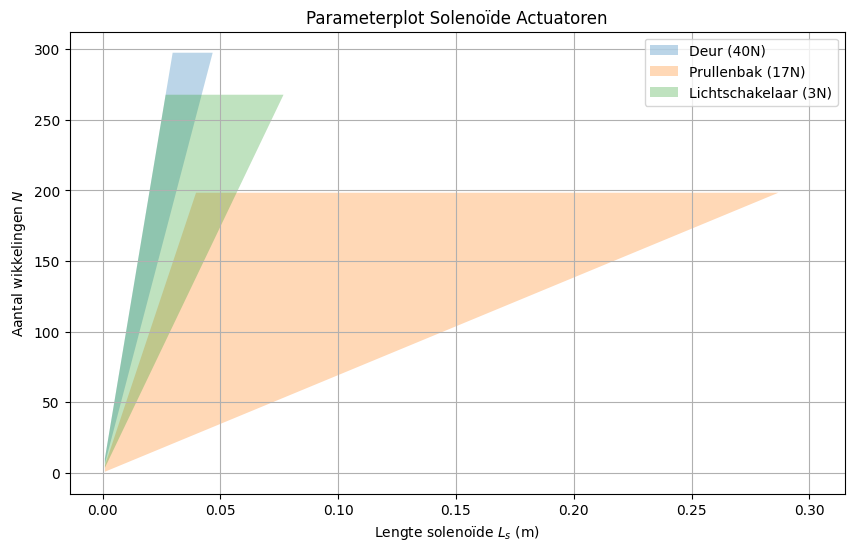

In [20]:
L_s_waarden = np.linspace(0.001, 0.3, 5000)

actuatoren = [relevante_parameters1, relevante_parameters2, relevante_parameters3]
labels = ["Deur (40N)", "Prullenbak (17N)", "Lichtschakelaar (3N)"]

plt.figure(figsize=(10, 6))

for i, params in enumerate(actuatoren):
    n_min_lijst = []
    n_max_lijst = []
    
    for l in L_s_waarden:
        # Update de huidige L_s in de dictionary
        params['L_s'] = l
        n_min, n_max = aantal_wikkelingen(params)
        
        # zet NaN om naar 0 voor de plot als er geen oplossing is
        n_min_lijst.append(n_min if n_min != 'NaN' else 0)
        n_max_lijst.append(n_max if n_max != 'NaN' else 0)
    
    # Maak de parameter plot voor deze actuator
    plt.fill_between(L_s_waarden, n_min_lijst, n_max_lijst, alpha=0.3, label=labels[i])

# Opmaak van de grafiek
plt.title("Parameterplot Solenoïde Actuatoren")
plt.xlabel("Lengte solenoïde $L_s$ (m)")
plt.ylabel("Aantal wikkelingen $N$")
plt.legend()
plt.grid(True)

plt.show()

The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable solution
The design with 40.0 N has no workable s

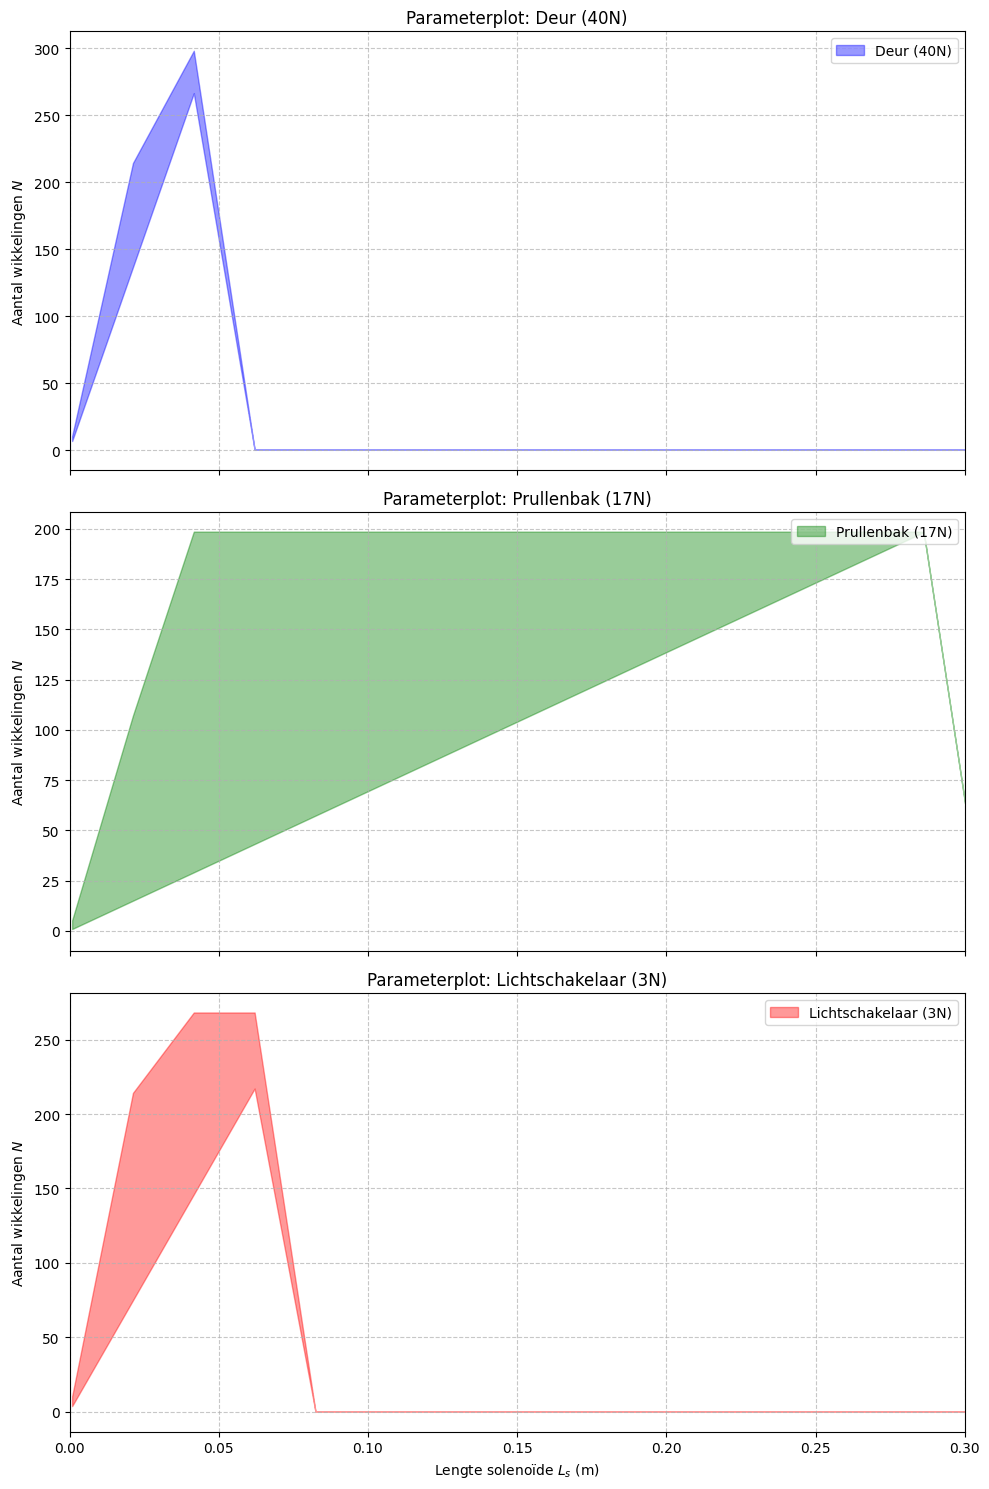

In [21]:
# 3 plots onder elkaar

L_s_waarden = np.linspace(0.001, 1, 50) 

actuatoren = [relevante_parameters1, relevante_parameters2, relevante_parameters3]
labels = ["Deur (40N)", "Prullenbak (17N)", "Lichtschakelaar (3N)"]
kleuren = ['blue', 'green', 'red']

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

for i, params in enumerate(actuatoren):
    n_min_lijst = []
    n_max_lijst = []
    
    for l in L_s_waarden:
        params['L_s'] = l
        n_min, n_max = aantal_wikkelingen(params)
        
        n_min_lijst.append(n_min if n_min != 'NaN' else 0)
        n_max_lijst.append(n_max if n_max != 'NaN' else 0)
    
    axes[i].fill_between(L_s_waarden, n_min_lijst, n_max_lijst, 
                         alpha=0.4, color=kleuren[i], label=labels[i])
    
    axes[i].set_xlim(0, 0.3)
    
    axes[i].set_title(f"Parameterplot: {labels[i]}")
    axes[i].set_ylabel("Aantal wikkelingen $N$")
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.7)

axes[2].set_xlabel("Lengte solenoïde $L_s$ (m)")

plt.tight_layout()
plt.show()

**Opdracht 10**

Maak voor elke actuator een keuze voor de lengte van de spoel, de straal van de spoel en de lengte van de draad.

Voor de prullenbak kiezen we voor de lengte van de spoel: 0.1 m, straal van de spoel: 0.015 m, lengte draad: 18.7 m. Voor de lichtschakelaar kiezen we voor de lengte van de spoel: 0.04 m, straal van de spoel: 0.005 m , lengte draad: 8.41 m. Voor de deur kiezen we voor de lengte van de spoel: 0.03 m, straal van de spoel: 0.01, lengte draad: 8.41 m.

Bovenstaande analytische berekening is een goede start voor het ontwerp en geeft aan welke parameters je kan optimaliseren. Echter in een echte solenoide zullen er allerlei niet ideale effecten een rol spelen. Zo zal het veld in de solenoide niet constant zijn (het is geen oneindig lange solenoide) en zijn er randvelden aan de uiteinden van de solenoide. We zullen nu de kracht-afstand relatie van de solenoide krachtactuator uitrekenen. Deze kan dan verder geoptimaliseerd worden om de kracht-uitwijking relatie zo lineair mogelijk te maken.

## Deel 4: Numeriek berekenen van het magneetveld van een rechte stroomdraad

<img align="right" style="margin-left:15px" src="wiregeometry.jpg" width="300">

Omdat we in ons ontwerp een stroombron gebruiken met een aangelegde stroom voeren we de berekeningen uit met het $\mathbf{H}$-veld. De analytische oplossing voor het $\mathbf{H}$-veld om een oneindig lange stroomdraad is het met meest eenvoudige voorbeeld voor het berekenen van het magnetisch veld en het toepassen van de wet van Ampere. In cilindrische coordinaten wordt het magneetveld op afstand $s$ veroorzaakt door stroom $I$ gegeven door (zie Griffiths blz. 282, voorbeeld 6.2)
$$
    \mathbf{B} =\frac{I}{2 \pi s} \hat{\boldsymbol{\phi}} \, .
$$


Alleen in de meest eenvoudige stroomgeometrieën kunnen we het magneetveld analytisch berekenen. In meer complexe stroomgeometrieën moeten we numerieke methoden gebruiken om het magneetveld te berekenen. In deze opdracht willen we een numerieke methode ontwikkelen voor een complexe stroomgeometrie, maar gebruiken we het voorbeeld van de oneindig lange stroomdraad om onze numerieke methode te testen. We gaan het magneetveld berekenen met de wet van Biot-Savart (zie Griffiths blz. 222, Vgl. 5.34) maar dan voor het $\mathbf{H}$-veld

$$
    \mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I \int \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

De wet van Biot-Savart laat zien dat het magneetveld wordt gegeven door een som over lijnelementen $d\mathbf{l}$ met bijdrage

$$
    d\mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I  \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

**Opdracht 11**

Schrijf een Python funktie met als invoer de variabelen:
* een array die de veldpositie $\mathbf{r}$ aangeeft
* een array die de de bronpositie $\mathbf{r}'$ aangeeft
* een array die de lengte $d\mathbf{l}$ aangeeft

De functie moet het magneetveld van een lijnelement $d\mathbf{l}$ berekenen. Gebruik voor het uitrekenen van het uitproduct de numpy $\verb|cross|$ functie en de hierboven gegeven formule voor $d\mathbf{H}$.

Bereken met deze functie alle componenten van het magneetveld voor een veldpositie op $x=0.1$ m voor een stroombronelement in de oorsprong met een stroom van 6 A een lengte van $d\mathbf{l}$ gelijk aan $L/64$. Print het analytische en numerieke antwoord naar de command line en controleer dat het magneetveld gelijk is aan $\mathbf{H} =  0.00746 \hat{\mathbf{y}}$ A/m is.

Nu gaan we met behulp van de numerieke implementatie van de wet van Biot-Savart het magneetveld uitrekenen in het vlak loodrecht op de draad. We nemen daarom een eindige lengte van de draad en verdelen dit in kleine stukken met lengte $d\mathbf{l}$. Daarna integreren we over de gehele lengte door de bijdrage van al deze stukken op te tellen en zo het magneetveld te bepalen. Voor het correct uitvoeren van deze numerieke integratie is het van belang dat we en een lang genoeg stuk draad nemen en dat we dit in genoeg kleine delen ophakken.

**Opdracht 12**
* Creëer een array met de veldcoordinaat $\mathbf{r}$.
* Bereken een array met alle contributies $dH$ op $r=(x,y,z)=(0.1, 0, 0)$ m.
* Plot de contributies tegen de locatie van de bijbehorende bron.
* Bereken het $H$ veld door over alle contributies te someren.
* Print een regel met het numerieke antwoord en vergelijk dit met het analytische antwoord.
* Bestudeer hoe de bijdragen varieren voor de verschillende locaties en hoe groot L en het aantal stappen moet zijn om een numeriek correct resultaat te krijgen.

Deze opdracht kan ook gemaakt worden met het gebruik van for loops, De akauze voor methode is aan jullie.

In [22]:
L_draad = 0.1                       # m
dl=np.array([0, 0, L_draad/64])         # lijnelement op positie z =  L_draad/64
r_field=np.array([0.1, 0, 0])       # x = 0.1 m
r_source=np.array([0, 0, 0])
I = 6           # A

def field_current_element(r_field, r_source, dl):
    # r_field are coordinates at which we want to calculate the field
    # r_source are coordinates of the current source
    # dl is the vector of the length of the current element
    # Gebruik np.cross om het uitproduct te berekenen
    r_vec = r_field - r_source
    r_norm = np.linalg.norm(r_vec)          # lengte van de vector
    cross_product = np.cross(dl, r_vec)
    dH = (I / (4 * np.pi)) * (cross_product / (r_norm**3))       # **3 omdat je in teller niet cross product met eenheidsvector
    return dH
analytical_answer=(I/(4 *np.pi))*(L_draad/64)/np.sum((r_field-r_source)**2) # een veld elementje.
print('The analytical answer is ' + str(analytical_answer) + ' A/m in the y-direction')             # analytisch = exact

print('The numerical answer is is ' + str(field_current_element(r_field, r_source, dl)) + ' A/m')     # numeriek = benaderd met iteraties


The analytical answer is 0.07460387957432593 A/m in the y-direction
The numerical answer is is [0.         0.07460388 0.        ] A/m


Numeriek H-veld: 9.364216 A/m
Analytisch (oneindig): 9.549297 A/m


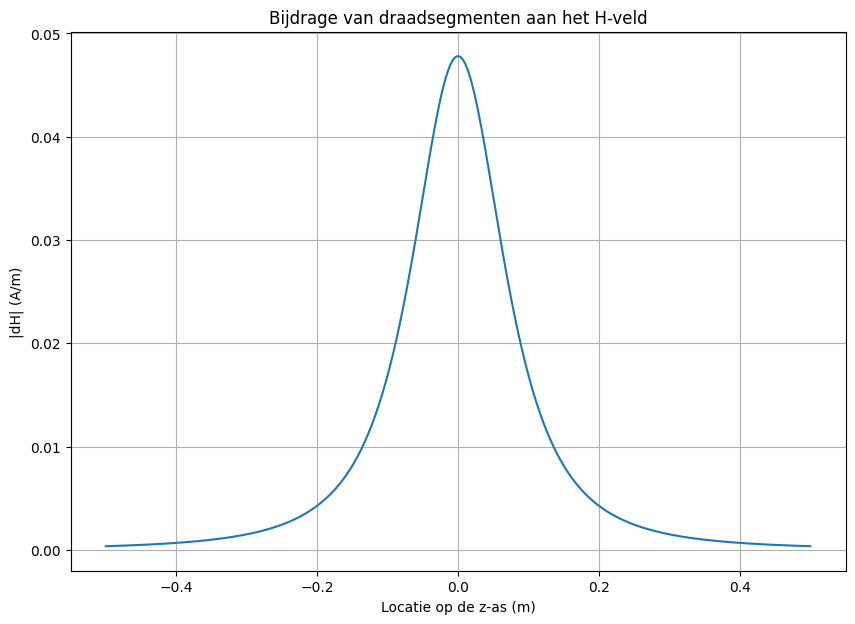

In [23]:
# Parameters
I = 6.0
L_draad = 1         # Begin met een redelijke lengte
n_stappen = 1000       # Aantal segmenten
r_veld = np.array([0.1, 0, 0])  # Het veldpunt

# Afgeleide
z_punten = np.linspace(-L_draad/2, L_draad/2, n_stappen)
dz_waarde = z_punten[1] - z_punten[0]
dl = np.array([0, 0, dz_waarde]) # Stroom loopt in de z-richting

# Lijsten om resultaten op te slaan voor de plot
contributies_norm = []
z_locaties = []
H_totaal = np.array([0.0, 0.0, 0.0])

# De Loop numeriek
for i in range(len(z_punten)):
    r_source = np.array([0, 0, z_punten[i]]) # Bron ligt op de z-as
    
    # Gebruik je eigen functie
    dH = field_current_element(r_veld, r_source, dl)
    
    H_totaal += dH
    
    # Sla de grootte (norm)
    contributies_norm.append(np.linalg.norm(dH))
    z_locaties.append(z_punten[i])

# Analytische Vergelijking
# Voor een oneindige rechte draad: H = I / (2 * pi * r)
r_afstand = 0.1
H_analytisch_inf = I / (2 * np.pi * r_afstand)

print(f"Numeriek H-veld: {np.linalg.norm(H_totaal):.6f} A/m")
print(f"Analytisch (oneindig): {H_analytisch_inf:.6f} A/m")

plt.figure(figsize=(10, 7))
plt.plot(z_locaties, contributies_norm)
plt.xlabel('Locatie op de z-as (m)')
plt.ylabel('|dH| (A/m)')
plt.title('Bijdrage van draadsegmenten aan het H-veld')
plt.grid(True)
plt.show()

### Deel 5: Numeriek berekenen van het magneetveld van een solenoide

We gaan nu het magneetveld van onze solenoide uitrekenen. Deze solenoide is een draad die om een cylinder gewikkeld is. Hieronder is een functie gegeven die de draad van een solenoide parametriseert. Deze parametrisatie gaan jullie gebruiken in combinatie met Biot-Savart om het H veld rond de solenoide te berekenen.

In [24]:
def parametrisatie(N,r_sol,aantal_omwentelingen,L_sol):
    t=np.linspace(0, 1, N)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen*t) # x coordinaten
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen*t) # y coordinaten
    z = L_sol* t - L_sol/2  # z componenten
    return x,y,z

**Opdracht 13**

Bereken het traject van een stroomdraad met een straal van $r_{sol}$. De solenoide met lengte $L_{sol}$ is gecentreerd op de oorsprong met de cilinderas langs de $z$-as. Doe dit door de hierboven gegeven functie te gebruiken.

a. Bereken het aantal omwentelingen van je draad, hierbij mag je aannemen dat de omtrek een cirkel is (in feite is het een ellips, maar omdat de windingen zo dicht op elkaar zitten is het vrijwel een cirkel).\
b. Bereken de $x$, $y$ en $z$ coordinaten.\
c. Bereken de spoed, in eenheden van aantal omwentelingen per meter, en print dit.

Het aantal_omwentelingen is: 133.84930714028397
De spoed van de solenoïde is: 4461.64 omwentelingen per meter


(Text(0.5, 0, 'x (m)'), Text(0.5, 0.5, 'y (m)'), Text(0.5, 0, 'z (m)'))

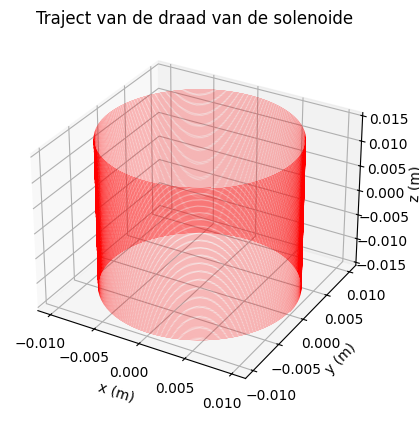

In [25]:
# deur
l_draad_d = 8.41 # Lengte draad
r_sol_d = 0.01 # Straal solenoide
L_sol_d = 0.03 # Lengte solenoide=
# N = # wikkelng
#a
# (Draadlengte})^2 = (Horizontale afstand)^2 + (Verticale afstand)^2 
# (Horizontale afstand) = np.sqrt((draadlengte)^2 - (Verticale afstand)^2 )
# horizontale afstand = N_omwentelingen * 2*pi*R_sol
# verticale afstand = L_sol
# draadlengte = l_draad
# np.sqrt(l_draad**2 - L_sol**2)
aantal_omwentelingend = l_draad_d / (2 * np.pi * r_sol_d)  # Aantal wikkeling
print('Het aantal_omwentelingen is:', aantal_omwentelingend)
# b
# N = aantal datapunten
N_punten = 10000 
x, y, z = parametrisatie(N_punten, r_sol_d, aantal_omwentelingend, L_sol_d)

#c
spoed = aantal_omwentelingend / L_sol_d
print(f"De spoed van de solenoïde is: {spoed:.2f} omwentelingen per meter")

# plots
ax=plt.figure().add_subplot(projection='3d')
plt.title('Traject van de draad van de solenoide')
plt.plot(x, y, z, '-r', linewidth=0.18)
ax.set_box_aspect(aspect=None, zoom=1.)
ax.set_xlabel('x (m)'), ax.set_ylabel('y (m)'), ax.set_zlabel('z (m)')

Het aantal_omwentelingen is: 198.4131623878962
De spoed van de solenoïde is: 1984.13 omwentelingen per meter


(Text(0.5, 0, 'x (m)'), Text(0.5, 0.5, 'y (m)'), Text(0.5, 0, 'z (m)'))

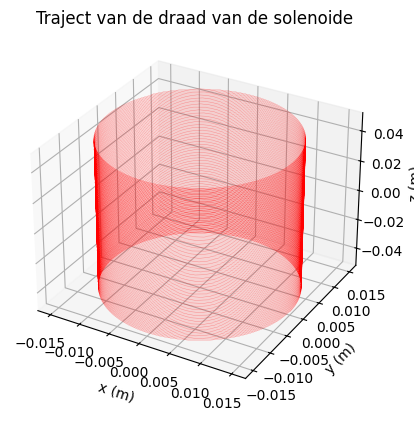

In [26]:
# prullenbak
# Voor de prullenbak kiezen we voor de lengte van de spoel: 0.1 m, straal van de spoel: 0.015 m, lengte draad: 18.7 m. 
l_draad = 18.7 # Lengte draad
r_sol = 0.015 # Straal solenoide
L_sol = 0.1 # Lengte solenoide=
# N = # wikkelng
#a
# (Draadlengte})^2 = (Horizontale afstand)^2 + (Verticale afstand)^2 
# (Horizontale afstand) = np.sqrt((draadlengte)^2 - (Verticale afstand)^2 )
# horizontale afstand = N_omwentelingen * 2*pi*R_sol
# verticale afstand = L_sol
# draadlengte = l_draad
aantal_omwentelingen = l_draad / (2 * np.pi * r_sol)  # Aantal wikkeling
print('Het aantal_omwentelingen is:', aantal_omwentelingen)
# b
# N = aantal datapunten
N_punten = 10000 
x, y, z = parametrisatie(N_punten, r_sol, aantal_omwentelingen, L_sol)

#c
spoed = aantal_omwentelingen / L_sol
print(f"De spoed van de solenoïde is: {spoed:.2f} omwentelingen per meter")

# plots
ax=plt.figure().add_subplot(projection='3d')
plt.title('Traject van de draad van de solenoide')
plt.plot(x, y, z, '-r', linewidth=0.1)
ax.set_box_aspect(aspect=None, zoom=1.)
ax.set_xlabel('x (m)'), ax.set_ylabel('y (m)'), ax.set_zlabel('z (m)')

Het aantal_omwentelingen is: 267.69861428056794
De spoed van de solenoïde is: 6692.47 omwentelingen per meter


(Text(0.5, 0, 'x (m)'), Text(0.5, 0.5, 'y (m)'), Text(0.5, 0, 'z (m)'))

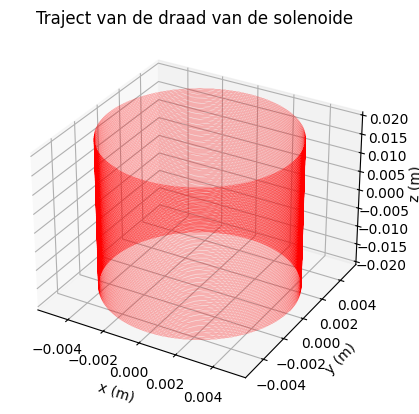

In [27]:
# lichtschakelaar
# Voor de lichtschakelaar kiezen we voor de lengte van de spoel: 0.04 m, straal van de spoel: 0.005 m , lengte draad: 8.41 m.
l_draad = 8.41 # Lengte draad
r_sol = 0.005 # Straal solenoide
L_sol = 0.04 # Lengte solenoide=
I = 0.5         # A
# N = # wikkelng
#a
# (Draadlengte})^2 = (Horizontale afstand)^2 + (Verticale afstand)^2 
# (Horizontale afstand) = np.sqrt((draadlengte)^2 - (Verticale afstand)^2 )
# horizontale afstand = N_omwentelingen * 2*pi*R_sol
# verticale afstand = L_sol
# draadlengte = l_draad
aantal_omwentelingen = l_draad / (2 * np.pi * r_sol)  # Aantal wikkeling
print('Het aantal_omwentelingen is:', aantal_omwentelingen)
# b
# N = aantal datapunten
N_punten = 10000 
x, y, z = parametrisatie(N_punten, r_sol, aantal_omwentelingen, L_sol)

#c
spoed = aantal_omwentelingen / L_sol
print(f"De spoed van de solenoïde is: {spoed:.2f} omwentelingen per meter")

# plots
ax=plt.figure().add_subplot(projection='3d')
plt.title('Traject van de draad van de solenoide')
plt.plot(x, y, z, '-r', linewidth=0.1)
ax.set_box_aspect(aspect=None, zoom=1.)
ax.set_xlabel('x (m)'), ax.set_ylabel('y (m)'), ax.set_zlabel('z (m)')

Het veld in een oneindig lange solenoide wordt gegeven door $\mathbf{H} = n I \hat{\mathbf{z}}$, met $n$ de spoed van de draad, en $I$ de stroom.

**Opdracht 14**

Bereken het veld in het midden van de solenoide en vergelijk het met het analytische antwoord voor een oneindig lange solenoide. Verhoog $N$ net zo lang tot jullie antwoord convergeert naar het analytisch antwoord.
* Denk na over wat dl betekent en hoe jullie deze zou berekenen.
* Bereken met de functie die jullie eerder geschreven hebben de contributies aan het $H$-veld en sommeer deze.

In [28]:
# Dit reken ik uit voor laatste geval: lichtschakelaar
# Voor de lichtschakelaar kiezen we voor de lengte van de spoel: 0.04 m, straal van de spoel: 0.005 m , lengte draad: 8.41 m.
# N = # wikkelng
# print
# H = nIz^
z_dakje = np.array([0,0,1])
H_analytisch = spoed * I * z_dakje
print('Het veld van oneindig lange solenoide analytisch:', H_analytisch)

N = N_punten

# Genereer de punten met je bestaande functie
x, y, z = parametrisatie(N, r_sol, aantal_omwentelingen, L_sol)
punten = np.vstack((x, y, z)).T

# Bereken het veld in het midden (oorsprong)
r_field = np.array([0, 0, 0])
H_totaal = np.array([0.0, 0.0, 0.0])

# De vector 'r' in Biot-Savart loopt van de draad naar het meetpunt (0,0,0) = midden van solenoid
# r_bron_naar_meetpunt = H_totaal - midden_dl

for i in range(len(punten) - 1):
    r_source = (punten[i] + punten[i+1]) / 2  # Het midden van het segmentje
    dl = punten[i+1] - punten[i]             # De vector van het segmentje
    
    # Gebruik bestaande functie 
    dH = field_current_element(r_field, r_source, dl)
    H_totaal += dH

print(f"Berekend H-veld in het midden: {H_totaal}")

Het veld van oneindig lange solenoide analytisch: [   0.            0.         3346.23267851]
Berekend H-veld in het midden: [4.30343177e-01 3.09809263e-01 3.25467499e+03]


### Deel 6: Bereken krachtrespons van een kracht actuator
Omdat onze solenoide niet oneindig lang is zal het veld in de solenoide niet uniform zijn en ook niet op alle plaatsen exact langs de as gericht zijn.

**Opdracht 15**

Bereken de $z$-component van het $\mathbf{H}$-veld op de as van de solenoide over het interval $z \in [0, 1.5L_s]$ in 25 stappen. Je moet nu dus op elk veld-punt met behulp Biot-Savart de bijdragen van alle stroomelementen integreren. Maak een grafiek van de $z$-component van het $\mathbf{H}$-veld tegen $z$.

L_sol: 0.03 m
aantal_omwentelingen: 133.84930714028397
Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield = 

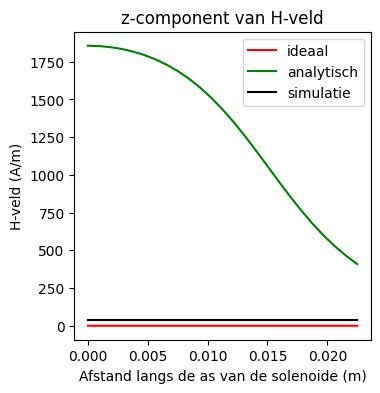

In [29]:
# deuractuator
l_draad = 8.41 # Lengte draad
r_sol = 0.01 # Straal solenoide
L_sol = 0.03 # Lengte solenoide
n_ax=25
z_ax=np.linspace(0, 1.5*L_sol/2, n_ax)      # voor elk van deze veldpunten moet de totale invloed van alle dl van de hele spoel worden gesommeerd
print('L_sol:', L_sol, 'm')
H_ax=np.zeros((n_ax,1))                     # kolom met 25 nullen

# aantal_omwent = aantal_omwentelingen
print('aantal_omwentelingen:', aantal_omwentelingend)
aantal_omwent = aantal_omwentelingend
N = 2100

for i_field in range(n_ax):         # loopt langs z-as van solenoid
    print(f"\rIfield =  {i_field}", end="") # Print welk element van het veld nu berekend wordt.
    # Bepaal de field coordinate
    Hsimulated=np.array([0,0,0], dtype='float64')           # indien bij nieuw veldpunt/ meetpunt aangekomen, wordt H weer op nul gezet.
    for i_source in np.arange(1, N):                    # hakt de draad/ de bron in N stukjes
        # Bepaal dl en r_source en gebruik
        Hsimulated += field_current_element(r_field, r_source, dl)          # dH wordt toegevoegd voor elke stukje dl
        print(f"Ifield =  {i_field}", end="")

    # selecting the z-component
    H_ax[i_field,0]=Hsimulated[2]           # H_ax is 25 lang in rij, en heeft 1 kolom. Vandaar de 0.

H_veld_ideaal=analytical_answer*np.ones(n_ax)*(1.0*(z_ax < L_sol/2))

# dit is nog een aardige analytische uitdrukking die je kan uitrekenen voor de z-component op de as van een solenoide met eindige lengte
H_veld_analytisch=(aantal_omwent*I/L_sol/2)*((L_sol/2-z_ax)/np.sqrt((z_ax- L_sol/2)**2 + r_sol**2)+(L_sol/2+z_ax)/np.sqrt((z_ax+ L_sol/2)**2 + r_sol**2))

plt.figure(figsize=[13,4])
plt.subplot(131)
plt.title('z-component van H-veld')
plt.plot(z_ax, H_veld_ideaal, '-r', label='ideaal')
plt.plot(z_ax, H_veld_analytisch, '-g', label='analytisch')
plt.plot(z_ax, H_ax, '-k', label='simulatie')
plt.xlabel('Afstand langs de as van de solenoide (m)')
plt.ylabel('H-veld (A/m)')
plt.legend()
plt.show()

We gaan de solenoide nu gebruiken voor onze krachtactuator. Daarvoor gaan we opnieuw de energie in het magnetisch veld berekenen, maar nu met het numerieke resultaat voor een eindige lengte solenoide. We gaan hier nu een aantal aannames maken:
* We nemen aan het veld alleen een $z$-component heeft en niet afhangt van de afstand tot de solenoide as
* We verwaarlozen de bijdrage aan de energie van het deel van de solenoide gevuld in lucht en integreren alleen het deel van ijzer in het $\mathbf{H}$ veld (dat mag omdat $\mu_r \gg 1$)
* De plunjer is oneindig lang

Zoals je uit je berekening voor het $\mathbf{H}$ kan zien is de energie van de plunjer in de solenoide groter dan voor de plunjer uit de solenoide. Dit komt doordat we de berekening doen met constante stroom. De verplaatsing van de plunjer geeft echter ook een veranderende flux ($d \Phi/dt$) die een tegen EMF geeft. Deze moet overwonnen worden door de stroombron die de arbeid levert. Het magneetveld verricht dus geen arbeid, dat doet de stroombron! We berekenen dit effect hier niet expliciet, maar nemen $-W$ als energie zodat de kracht de juiste kant op wijst (de solenoide in, dus een kracht in de $-z$ richting).


**Opdracht 16**

* Bereken de energie als functie van de afstand van de plunjer in de solenoide met behulp van onderstaand script

0.01
0.03
1000


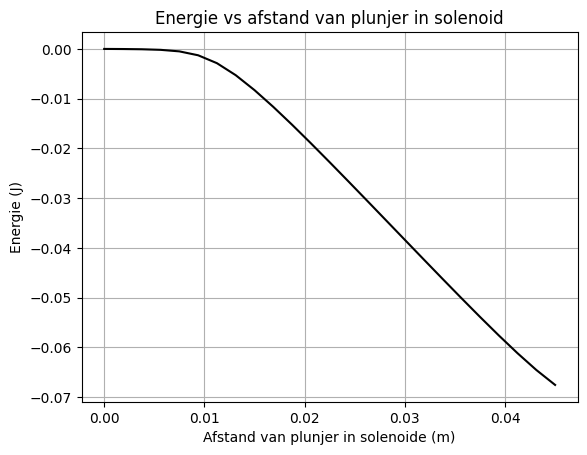

In [31]:
# deur
# integrate the field up to point z_p
# Energie-dichtheid : du / dB = H -> u = 1/2 * mu * H^2 ( J/ m^2 )
mu_0 = 4 * np.pi * 1e-7
r_s = 0.01
print(r_s)
L_s = 0.03
print(L_s)
mu_r = 1000
Oppervlakte = np.pi * r_s**2
z_ax = np.linspace(-L_sol, L_sol/2, 25) # Meetpunten langs de as
H_lijst = []

for z_meetpunt in z_ax:
    r_field = np.array([0, 0, z_meetpunt]) # Verplaats het meetpunt
    H_punt = np.array([0.0, 0.0, 0.0])
    
    for i in range(len(punten) - 1):
        r_source = (punten[i] + punten[i+1]) / 2
        dl = punten[i+1] - punten[i]
        dH = field_current_element(r_field, r_source, dl)
        H_punt += dH
        
    H_lijst.append(H_punt[2]) # Sla alleen de z-component op

# Nu cumsum gebruiken voor de energie:
H_ax = np.array(H_lijst)
Wz = -0.5 * Oppervlakte * mu_0 * mu_r * np.cumsum(H_ax**2) * (z_ax[1]-z_ax[0])      # Arbeid in z-richting = -1/2 * A * mu0 * mur * H ^2 

# hoever is plunjer naar binnen
# start begint plunjer aan rechterkant van spoel en wordt naar links in -z-richting getrokken.
plt.plot(L_s/2 - z_ax, np.flipud(Wz), '-k')
plt.title('Energie vs afstand van plunjer in solenoid')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Energie (J)'), plt.grid()
print(mu_r)

(-100.0, 0.0)

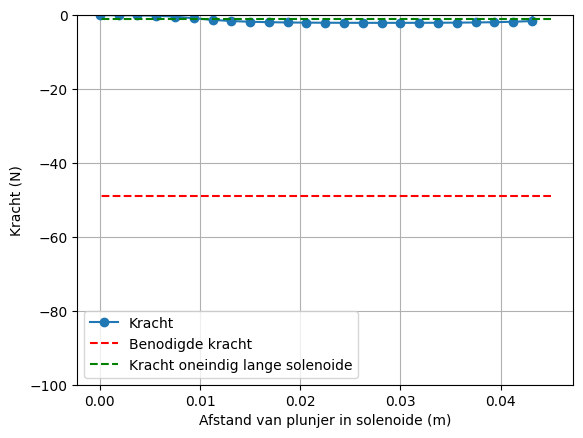

In [32]:
force_analytical = -mu_0*mu_r*np.pi*r_s**2*aantal_omwent**2*I**2/2/L_s**2 # Kracht uitrekenen numeriek
force_numerical=np.diff(Wz, n=1, append=[0])/(z_ax[1] - z_ax[0]) # Kracht uitrekenen

# Plotting the results
plt.plot(L_s/2 - z_ax, np.flipud(force_numerical), '-o', label='Kracht')
plt.plot(L_s/2 - z_ax, (-5*9.8)*np.ones(n_ax), '--r', label='Benodigde kracht')
plt.plot(L_s/2 - z_ax, force_analytical*np.ones(n_ax), '--g', label='Kracht oneindig lange solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Kracht (N)'), plt.grid(), plt.legend()
plt.ylim([-100, 0])

### Deel 7: Beoordeling van de criteria
**Opdracht 17**

Kijk in deze vraag terug naar de criteria die jullie voor de deuractuator hebben opgesteld. Voldoet jullie ontwerp aan alle gestelde criteria?


Plaats hier jullie evaluatie of de deur actuator aan de minimale kracht eis voldoet

Levert de spoel bij 9V en een straal van 0,01 m daadwerkelijk 40 Newton? Het criterium voor een deur was dat de deur van het slot moet gaan binnen 2 seconden. Het aantal omwentelingen is 133, gebaseerd op de maximale draadlengte van 8,41 meter. In de grafiek is te zien dat de grafieklijn voor de kracht van de oneindig lange solenoide hoger ligt dan de grafieklijn voor de benodigde kracht. De kracht van de oneindig lange solenoide is de kracht die maximaal haalbaar is op basis van de eigenschappen van de actuator (lengte, straal, stroom, etc.), aagezien de benodigde kracht groter is dan deze maximaal haalbare kracht, wordt er dus niet voldaan aan de eis voor de kracht van de deuractuator. We zijn hierbij gelimiteerd in de beperkte keuze van stroombronnen die ons werd aangereikt.

**Opdracht 18**

Voer opdrachten 15 en 16 uit voor jouw eigen gekozen toepassingen.

aantal_omwentelingen: 198.4131623878962
Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24

Text(0, 0.5, 'B-veld (Tesla)')

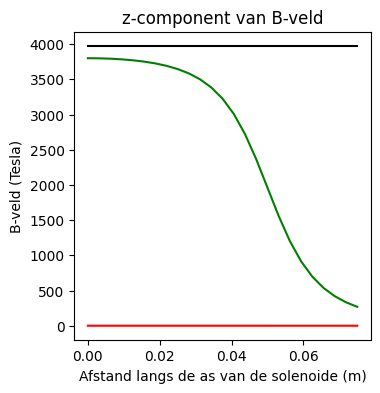

In [33]:
###
####### 15
# prullenbak (17 N)
# telefoonoplader (vermogen= 40 Watt), 2 A, 20 V, 0.2 mm
F_prullenbak = 17 # N
U_batteryp = 20 # V
I_batteryp = 2 #A
draaddikte_spoelp = 0.2/1000 # m

I = I_batteryp
l_draad = 18.7 # Lengte draad
r_sol = 0.015 # Straal solenoide
L_sol = 0.1 # Lengte solenoide
n_ax=25
z_ax=np.linspace(0, 1.5*L_sol/2, n_ax)
H_ax=np.zeros((n_ax,1))

# aantal_omwent = aantal_omwentelingen
aantal_omwentelingenp = l_draad / (2 * np.pi * r_sol) 
print('aantal_omwentelingen:', aantal_omwentelingenp)
aantal_omwent = aantal_omwentelingenp
N = 2100

for i_field in range(n_ax):
    print(f"\rIfield =  {i_field}", end="") # Print welk element van het veld nu berekend wordt.
    # Bepaal de field coordinate
    Hsimulated=np.array([0,0,0], dtype='float64')
    for i_source in np.arange(1, N):
        # Bepaal dl en r_source en gebruik
        Hsimulated += field_current_element(r_field, r_source, dl)
        print(f"Ifield =  {i_field}", end="")

    # selecting the z-component
    H_ax[i_field,0]=Hsimulated[2]

H_veld_ideaal=analytical_answer*np.ones(n_ax)*(1.0*(z_ax < L_sol/2))

# dit is nog een aardige analytische uitdrukking die je kan uitrekenen voor de z-component op de as van een solenoide met eindige lengte
H_veld_analytisch=(aantal_omwent*I/L_sol/2)*((L_sol/2-z_ax)/np.sqrt((z_ax- L_sol/2)**2 + r_sol**2)+(L_sol/2+z_ax)/np.sqrt((z_ax+ L_sol/2)**2 + r_sol**2))

plt.figure(figsize=[13,4])
plt.subplot(131)
plt.title('z-component van B-veld')
plt.plot(z_ax, H_veld_ideaal, '-r', label='ideaal')
plt.plot(z_ax, H_veld_analytisch, '-g', label='analytisch')
plt.plot(z_ax, H_ax, '-k', label='simulatie')
plt.xlabel('Afstand langs de as van de solenoide (m)')
plt.ylabel('B-veld (Tesla)')
###

0.015
0.1
1000


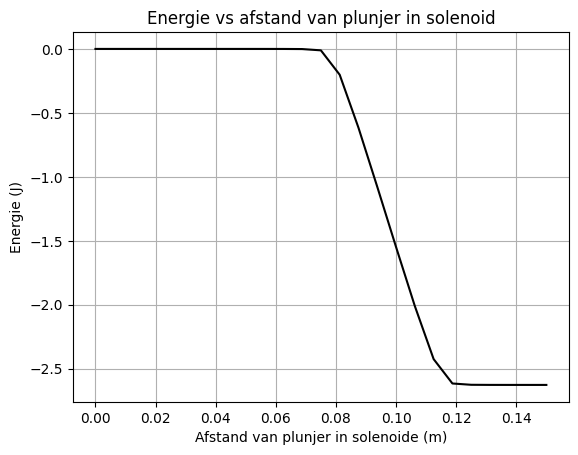

In [34]:
#### 16
# prullenbak
# integrate the field up to point z_p
# Energie-dichtheid : du / dB = H -> u = 1/2 * mu * H^2 ( J/ m^2 )
r_s = r_sp
print(r_s)
L_s = 0.1
print(L_s)
mu_r = 1000
Oppervlakte = np.pi * r_s**2
z_ax = np.linspace(-L_sol, L_sol/2, 25) # Meetpunten langs de as
H_lijst = []

for z_meetpunt in z_ax:
    r_field = np.array([0, 0, z_meetpunt]) # Verplaats het meetpunt
    H_punt = np.array([0.0, 0.0, 0.0])
    
    for i in range(len(punten) - 1):
        r_source = (punten[i] + punten[i+1]) / 2
        dl = punten[i+1] - punten[i]
        dH = field_current_element(r_field, r_source, dl)
        H_punt += dH
        
    H_lijst.append(H_punt[2]) # Sla alleen de z-component op

# Nu cumsum gebruiken voor de energie:
H_ax = np.array(H_lijst)
Wz = -0.5 * Oppervlakte * mu_0 * mu_r * np.cumsum(H_ax**2) * (z_ax[1]-z_ax[0])      # Arbeid in z-richting = -1/2 * A * mu0 * mur * H ^2 

# hoever is plunjer naar binnen
# start begint plunjer aan rechterkant van spoel en wordt naar links in -z-richting getrokken.
plt.plot(L_s/2 - z_ax, np.flipud(Wz), '-k')
plt.title('Energie vs afstand van plunjer in solenoid')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Energie (J)'), plt.grid()
print(mu_r)

(-100.0, 0.0)

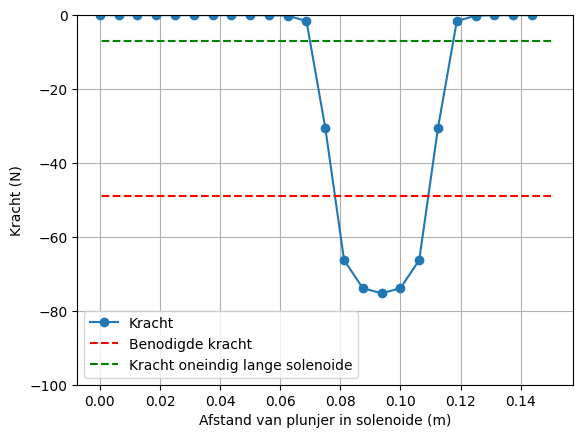

In [35]:
force_analytical = -mu_0*mu_r*np.pi*r_s**2*aantal_omwent**2*I**2/2/L_s**2 # Kracht uitrekenen numeriek
force_numerical=np.diff(Wz, n=1, append=[0])/(z_ax[1] - z_ax[0]) # Kracht uitrekenen

# Plotting the results
plt.plot(L_s/2 - z_ax, np.flipud(force_numerical), '-o', label='Kracht')
plt.plot(L_s/2 - z_ax, (-5*9.8)*np.ones(n_ax), '--r', label='Benodigde kracht')
plt.plot(L_s/2 - z_ax, force_analytical*np.ones(n_ax), '--g', label='Kracht oneindig lange solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Kracht (N)'), plt.grid(), plt.legend()
plt.ylim([-100, 0])

aantal_omwentelingen: 267.69861428056794
Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  24Ifield =  2

Text(0, 0.5, 'B-veld (Tesla)')

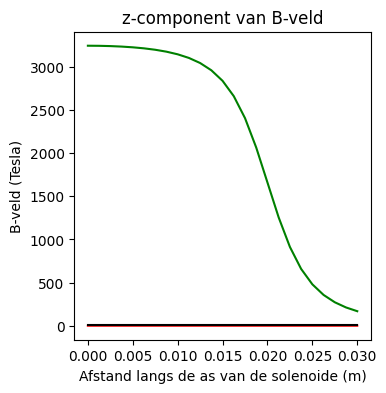

In [36]:
###### 15
# lichtschakelaar (3 N)
# Batterij (vermogen= 4.5 Watt), 500 mA, 9 V, 0.1 mm
F_lichtschakelaar = 3 # N
U_batteryl = 9 # V
I_batteryl = 500/1000 #A
draaddikte_spoell = 0.1/1000 # m
I = I_batteryl

l_draad = 8.41 # Lengte draad
r_sol = 0.005 # Straal solenoide
L_sol = 0.04 # Lengte solenoide
n_ax=25
z_ax=np.linspace(0, 1.5*L_sol/2, n_ax)
H_ax=np.zeros((n_ax,1))

# aantal_omwent = aantal_omwentelingen
aantal_omwentelingenl = l_draad / (2 * np.pi * r_sol) 
print('aantal_omwentelingen:', aantal_omwentelingenl)
aantal_omwent = aantal_omwentelingenl
N = 2100

for i_field in range(n_ax):
    print(f"\rIfield =  {i_field}", end="") # Print welk element van het veld nu berekend wordt.
    # Bepaal de field coordinate
    Hsimulated=np.array([0,0,0], dtype='float64')
    for i_source in np.arange(1, N):
        # Bepaal dl en r_source en gebruik
        Hsimulated += field_current_element(r_field, r_source, dl)
        print(f"Ifield =  {i_field}", end="")

    # selecting the z-component
    H_ax[i_field,0]=Hsimulated[2]

H_veld_ideaal=analytical_answer*np.ones(n_ax)*(1.0*(z_ax < L_sol/2))

# dit is nog een aardige analytische uitdrukking die je kan uitrekenen voor de z-component op de as van een solenoide met eindige lengte
H_veld_analytisch=(aantal_omwent*I/L_sol/2)*((L_sol/2-z_ax)/np.sqrt((z_ax- L_sol/2)**2 + r_sol**2)+(L_sol/2+z_ax)/np.sqrt((z_ax+ L_sol/2)**2 + r_sol**2))

plt.figure(figsize=[13,4])
plt.subplot(131)
plt.title('z-component van B-veld')
plt.plot(z_ax, H_veld_ideaal, '-r', label='ideaal')
plt.plot(z_ax, H_veld_analytisch, '-g', label='analytisch')
plt.plot(z_ax, H_ax, '-k', label='simulatie')
plt.xlabel('Afstand langs de as van de solenoide (m)')
plt.ylabel('B-veld (Tesla)')

0.005
0.04
1000


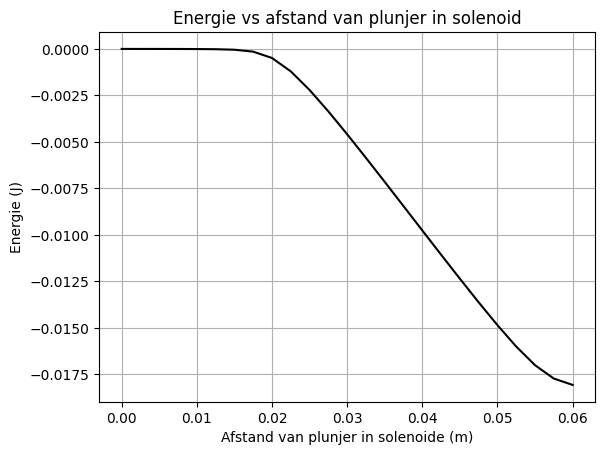

In [37]:
#### 16
# licht
# integrate the field up to point z_p
# Energie-dichtheid : du / dB = H -> u = 1/2 * mu * H^2 ( J/ m^2 )
r_s = r_sl
print(r_s)
L_s = 0.04
print(L_s)
mu_r = 1000
Oppervlakte = np.pi * r_s**2
z_ax = np.linspace(-L_sol, L_sol/2, 25) # Meetpunten langs de as
H_lijst = []

for z_meetpunt in z_ax:
    r_field = np.array([0, 0, z_meetpunt]) # Verplaats het meetpunt
    H_punt = np.array([0.0, 0.0, 0.0])
    
    for i in range(len(punten) - 1):
        r_source = (punten[i] + punten[i+1]) / 2
        dl = punten[i+1] - punten[i]
        dH = field_current_element(r_field, r_source, dl)
        H_punt += dH
        
    H_lijst.append(H_punt[2]) # Sla alleen de z-component op

# Nu cumsum gebruiken voor de energie:
H_ax = np.array(H_lijst)
Wz = -0.5 * Oppervlakte * mu_0 * mu_r * np.cumsum(H_ax**2) * (z_ax[1]-z_ax[0])      # Arbeid in z-richting = -1/2 * A * mu0 * mur * H ^2 

# hoever is plunjer naar binnen
# start begint plunjer aan rechterkant van spoel en wordt naar links in -z-richting getrokken.
plt.plot(L_s/2 - z_ax, np.flipud(Wz), '-k')
plt.title('Energie vs afstand van plunjer in solenoid')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Energie (J)'), plt.grid()
print(mu_r)

(-10.0, 0.0)

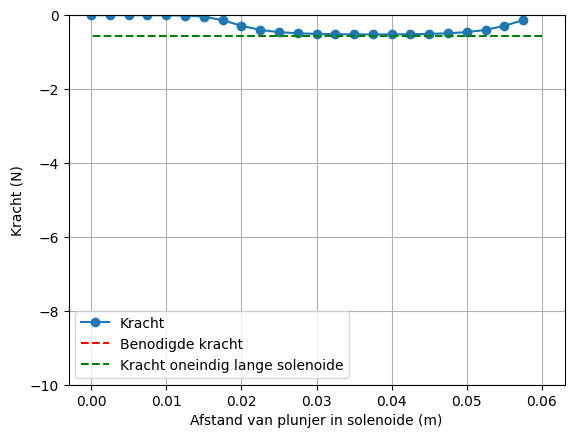

In [38]:
force_analytical = -mu_0*mu_r*np.pi*r_s**2*aantal_omwent**2*I**2/2/L_s**2 # Kracht uitrekenen numeriek
force_numerical=np.diff(Wz, n=1, append=[0])/(z_ax[1] - z_ax[0]) # Kracht uitrekenen

# Plotting the results
plt.plot(L_s/2 - z_ax, np.flipud(force_numerical), '-o', label='Kracht')
plt.plot(L_s/2 - z_ax, (-5*9.8)*np.ones(n_ax), '--r', label='Benodigde kracht')
plt.plot(L_s/2 - z_ax, force_analytical*np.ones(n_ax), '--g', label='Kracht oneindig lange solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Kracht (N)'), plt.grid(), plt.legend()
plt.ylim([-10, 0])

**Opdracht 19**

a. Kijk terug naar de criteria die jullie hebben opgesteld in vraag 5. Hebben jullie nu genoeg informatie om te beoordelen of jullie ontwerp voldoet aan de gestelde criteria, zo nee ontwerp een simpel experiment waarmee jullie het wel zouden uit kunnen voeren.
b. Beoordeel op basis van de criteria die jullie wel kunnen beoordelen of jullie idee voldoet aan jullie criteria.

# 19a
--------
De criteria voor de prullenbakactuator zijn een minimale openingshoek van 60 graden en een geleverde kracht van 17 N bij een stroomsterkte van 2 A. De criteria van de lichtschakelaar waren dat het in 0.1 sec moet worden omgeschakeld en dat de benodigde kracht van 3 N moet worden geleverd mbv een stroomsterkte van 0.5 A. De huidige configuratie (de gekozen straal, lengte, draaddikte en het aantal windingen) levert in combinatie met de specifieke stroomsterkte voldoende kracht. Om te bepalen of het ontwerp moet worden veranderd of dat de parameters moeten worden veranderd, is voor beide criteria (anders dan kracht) van de prullenbak en de lichtschakelaar een fysiek experiment nodig.

* prullenbak: 
We stellen een experiment voor met een handgewikkelde spoel en een plunjer. Door een bekend gewicht (bijv. 20 gram) aan de plunjer te hangen, kunnen we met een multimeter exact meten bij welke stroomsterkte het gewicht wordt opgetild. Hierdoor kunnen we bepalen of de stroombron van 2 Ampère en de draaddikte van 0,2 mm volstaan om 17 N te leveren, of dat de parameters moeten worden aangepast.

* prullenbak: Om te bepalen of de prullenbakdeur daadwerkelijk een hoek van 60 graden kan bereiken, is een meting van het krachtmoment nodig. Door met een unster loodrecht op de klep te trekken, meten we de kracht die nodig is om de klep op 60 graden open te houden. Vermenigvuldigd met de afstand tot het scharnier geeft dit het benodigde torque ($\tau = F \cdot r$). Als je actuator een kracht $F_{act}$ levert op een afstand $d$ van het scharnier, moet gelden: $$F_{act} \cdot d > \tau_{gemeten}$$

* Lichtschakelaar:
Voor de krachtmeting (3 N ) hangen we een gewicht van 300 gram (3 N) aan de plunjer van de actuator. Met een multimeter en een voeding meten we vervolgens of de plunjer dit gewicht bij een stroomsterkte van exact 0,5 A omhoog kan trekken.

* Lichtschakelaar:
Voor de snelheidsmeting (0,1 sec) maken we gebruik van een smartphone met een slow-motion camera. Door het omschakelmoment te filmen en naderhand het aantal frames te tellen tussen de start van de beweging en de volledige omslag, kunnen we de tijd heel nauwkeurig bepalen.

--------
# 19b
--------
Voor de prullenbak toont de simulatie aan dat de benodigde kracht wordt gehaald bij (z_plunjer = 8 - 11 cm voor 17 N). Ook bij de lichtschakelaar wijst de simulatie op voldoende kracht (z_plunjer = 4 - 8 cm voor 3 N) .

--------

Controleer eerst nog goed of alles klopt. **Klik boven op `Kernel -> Restart and Run all` en check of er geen errors zijn**. Zorg dat alle benodigde bestanden zijn geüpload in de juiste map en dat de afbeeldingen zichtbaar zijn in het notebook. Je kan nu jouw notebook opslaan, comitten en pushen naar de juiste branch! Maak dan de pull request aan en lever die in in brightspace.